# Customer churn prediction model
## Objective
To develop a classification model that estimates the probability that a customer will churn.

The model will be used to:
1. identify customers with elevated churn risk
2. determine which customer characteristics contribute useful predictive information when considered simultaneously
3. support customer segmentation for targeted retention strategies

## 1. Setup

The cleaned customer dataset is loaded and prepared for predictive modeling. 
Scikit-learn will be used for processing, model training and evaluation.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
telco_clean_df = pd.read_csv("../../1_data/2_processed/telco_churn_clean.csv")

In [3]:
telco_clean_df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
telco_clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   str    
 1   gender             7043 non-null   str    
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   str    
 4   dependents         7043 non-null   str    
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   str    
 7   multiple_lines     7043 non-null   str    
 8   internet_service   7043 non-null   str    
 9   online_security    7043 non-null   str    
 10  online_backup      7043 non-null   str    
 11  device_protection  7043 non-null   str    
 12  tech_support       7043 non-null   str    
 13  streaming_tv       7043 non-null   str    
 14  streaming_movies   7043 non-null   str    
 15  contract           7043 non-null   str    
 16  paperless_billing  7043 non-null   

In [5]:
#converrting the target variable to binary
telco_clean_df["churn"] = telco_clean_df["churn"].map({'Yes': 1, 'No': 0})

In [6]:
telco_clean_df["churn"].value_counts(normalize=True)

churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [7]:
X = telco_clean_df.drop(columns=["customer_id", "churn"])
y = telco_clean_df["churn"]

In [8]:
X.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [9]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [10]:
X.shape

(7043, 19)

In [11]:
y.shape

(7043,)

In [12]:
#splitting the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
y_train.value_counts(normalize=True)

churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [14]:
y_test.value_counts(normalize=True)

churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [15]:
#defining the categorical and numerical features
numerical_features = [
    "senior_citizen",
    "tenure",
    "monthly_charges",
    "total_charges"
]

In [16]:
categorical_features = [
    col for col in X.columns if col not in numerical_features
]

In [17]:
numerical_features

['senior_citizen', 'tenure', 'monthly_charges', 'total_charges']

In [18]:
categorical_features

['gender',
 'partner',
 'dependents',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method']

In [19]:
#building the preprocessing pipeline
numeric_transformer = Pipeline(
    steps = [
        ("scaler", StandardScaler())
    ]
)

In [20]:
categorical_transformer = Pipeline(
    steps = [
        ("onehot", OneHotEncoder(drop="first",handle_unknown="ignore"))
    ]
)

In [21]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 2. Baseline performance

Because the taret variable is imbalanced, a majority-class baseline is established before model training.

In [22]:
#establishing the baseline accuracy for the model 
baseline_accuracy = y_train.value_counts(normalize=True).max()

## 3. Logistic regression

Logistic regression is used as the first predictive model because the target variable, customer churn, is binary.

The model provides an interpretable baseline and allows the relationship between customer characteristics and churn probability to be examined while considering multiple predictors simultaneously.

Model performance will be evaluated using accuracy, precision, recall, F1-score, ROC-AUC and the confusion matrix.

In [23]:
logistic_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

In [24]:
#training the logistic regression model
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [25]:
#generating two types of predictions on the test set
y_pred = logistic_model.predict(X_test)

In [26]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [27]:
#calculating evaluation metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [28]:
#creating a model_performace table to store the evaluation metrics

logistic_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
       f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

logistic_metrics["Score"] = logistic_metrics["Score"].round(3)

logistic_metrics

,Metric,Score
0,Accuracy,0.807
1,Precision,0.660
2,Recall,0.561
3,F1 Score,0.607
4,ROC-AUC,0.842


### Accuracy

The logistic regression model achieved **80.6% accuracy**, meaning that
approximately four out of five customers in the test set were classified
correctly.

This exceeds the majority-class baseline of approximately 73%, indicating
that the model provides predictive value beyond simply predicting that
every customer will remain.

However, accuracy alone is insufficient because the dataset contains
substantially more retained customers than churned customers.

In [29]:
print(f"Baseline accuracy: {baseline_accuracy: 3f}")
print(f"Logistic accuracy: {accuracy_score(y_test, y_pred): 3f}")

Baseline accuracy:  0.734647
Logistic accuracy:  0.806955


### Precision

The model achieved **65.7% precision** for the churn class.

Among customers classified as likely to churn, approximately 66% actually
churned. The remaining predictions were false positives: customers flagged
for churn who ultimately remained.

Precision is relevant to retention strategy because false positives may
result in unnecessary retention spending if incentives are offered to
customers who would have remained without intervention.

### Recall

The model achieved **55.9% recall**, correctly identifying 209 of the
374 customers who actually churned.

However, 165 churners were classified as retained customers. This means
the model failed to identify approximately **44% of actual churners**.

For a retention use case, these false negatives are particularly important
because they represent customers who may not receive an intervention despite
being at risk of leaving.

### F1 Score

The model achieved an **F1 score of 0.604**, reflecting the balance between
precision and recall for the churn class.

The result indicates moderate performance in identifying churners while
limiting false-positive predictions. The lower recall relative to precision
suggests that the current model is relatively conservative in classifying
customers as likely to churn.

### ROC-AUC

The model achieved an **ROC-AUC of 0.842**, indicating strong ability to
distinguish between customers who churn and customers who remain across
classification thresholds.

This suggests that the model's underlying churn probabilities contain
useful ranking information, even though the default 0.50 classification
threshold currently misses a meaningful proportion of actual churners.

In [30]:
#classification report
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

              precision    recall  f1-score   support

      Stayed       0.85      0.90      0.87      1035
     Churned       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [31]:
#creating the confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm

array([[927, 108],
       [164, 210]])

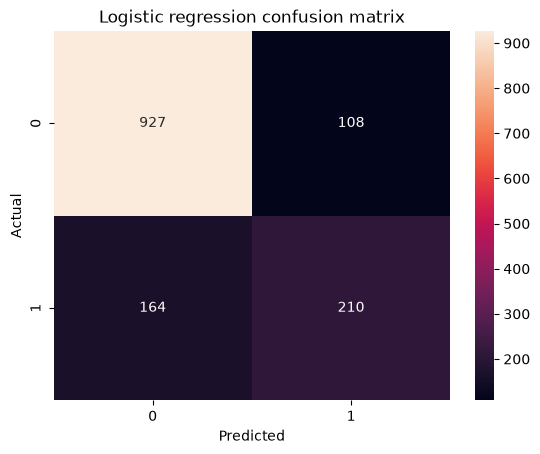

In [32]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic regression confusion matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### Confusion matrix interpretation

The confusion matrix shows how the model's predictionsare discributed across four outcomes:

-  true negatives - customers correctly predicted to remain
-  true positives - customers correctly identified as churners
-  false positives - retained customers incorrectly classified as churners
-  false negatives - churned customers the model failed to identify

From a retention perspective, false negatives are particularly important because they represent missed opportunities for intervention. False positives also carry a potential cost if retention incentives are provided to customers who would have remained without intervention.

| Outcome         | Customers | Business meaning                                            |
| --------------- | --------: | ----------------------------------------------------------- |
| True negatives  |   **927** | Correctly identified customers who remain                   |
| False positives |   **108** | Potential unnecessary retention targeting                   |
| False negatives |   **164** | Potential missed retention opportunities                    |
| True positives  |   **210** | Churners successfully identified for potential intervention |


### Logistic Regression Performance Summary

The logistic regression model achieved **80.6% accuracy** and an
**ROC-AUC of 0.842**, outperforming the majority-class baseline and
demonstrating good ability to distinguish between higher- and lower-risk
customers.

For the churn class, the model achieved **65.7% precision** and **55.9%
recall**. Of the 318 customers classified as churners, 209 actually
churned. However, the model identified only 209 of the 374 actual churners,
leaving **165 churners undetected**.

From a retention perspective, this represents an important trade-off.
The current model is relatively conservative when identifying churners,
which limits unnecessary targeting but results in missed retention
opportunities.

The strong ROC-AUC relative to the moderate recall suggests that the
model's predicted probabilities contain useful ranking information.
Subsequent threshold analysis should therefore evaluate whether a lower
classification threshold can improve churn detection while maintaining
an acceptable level of precision.

## 4. Logistic Regression Feature Effects

In [33]:
#examining individual predicted probabilities
prediction_results = X_test.copy()

prediction_results["actual_churn"] = y_test
prediction_results["predicted_churn"] = y_pred
prediction_results["churn_probability"] = y_prob

In [34]:
prediction_results[
    [
        "actual_churn",
        "predicted_churn",
        "churn_probability"
    ]
].head(10)

,actual_churn,predicted_churn,churn_probability
437,0,0,0.045839
2280,0,1,0.683758
2235,0,0,0.060072
4460,0,0,0.399365
3761,0,0,0.021614
5748,0,1,0.602268
3568,0,0,0.447143
2976,0,0,0.128906
5928,0,0,0.002897
1639,1,0,0.396051


In [35]:
#sorting out high probability churners
prediction_results.sort_values(
    "churn_probability",
    ascending=False
).head(10)

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,...,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,actual_churn,predicted_churn,churn_probability
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,1,1,0.855107
6866,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,1,1,0.832080
2631,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.25,665.45,1,1,0.827946
6365,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,101.95,700.85,1,1,0.823041
4585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,1,1,0.818811
3727,Female,0,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,96.60,291.90,1,1,0.818052
2797,Male,0,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,100.95,329.95,1,1,0.817840
6894,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,1,1,0.817163
3346,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,84.05,186.05,0,1,0.817010
935,Female,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,Yes,No,Month-to-month,Yes,Electronic check,83.25,308.05,0,1,0.811211


In [36]:
#extracting the feature names from the preprocessor
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [37]:
feature_names

array(['num__senior_citizen', 'num__tenure', 'num__monthly_charges',
       'num__total_charges', 'cat__gender_Male', 'cat__partner_Yes',
       'cat__dependents_Yes', 'cat__phone_service_Yes',
       'cat__multiple_lines_No phone service', 'cat__multiple_lines_Yes',
       'cat__internet_service_Fiber optic', 'cat__internet_service_No',
       'cat__online_security_No internet service',
       'cat__online_security_Yes',
       'cat__online_backup_No internet service', 'cat__online_backup_Yes',
       'cat__device_protection_No internet service',
       'cat__device_protection_Yes',
       'cat__tech_support_No internet service', 'cat__tech_support_Yes',
       'cat__streaming_tv_No internet service', 'cat__streaming_tv_Yes',
       'cat__streaming_movies_No internet service',
       'cat__streaming_movies_Yes', 'cat__contract_One year',
       'cat__contract_Two year', 'cat__paperless_billing_Yes',
       'cat__payment_method_Credit card (automatic)',
       'cat__payment_method_Elec

In [38]:
#extracting coefficients from the logistic regression model
coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

In [39]:
coef_df = pd.DataFrame(
    {"feature": feature_names, "coefficient": coefficients}
)

In [40]:
coef_df.head()

,feature,coefficient
0,num__senior_citizen,0.054651
1,num__tenure,-1.250481
2,num__monthly_charges,-0.470779
3,num__total_charges,0.523110
4,cat__gender_Male,0.022561


In [41]:
coef_df["feature"] = (
    coef_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

In [42]:
coef_df.head()

,feature,coefficient
0,senior_citizen,0.054651
1,tenure,-1.250481
2,monthly_charges,-0.470779
3,total_charges,0.523110
4,gender_Male,0.022561


In [43]:
#sorting the coefficients by highest positive impact on churn
coef_df.sort_values(
    "coefficient",
    ascending=False
).head(10)

,feature,coefficient
10,internet_service_Fiber optic,1.182298
3,total_charges,0.523110
28,payment_method_Electronic check,0.383863
21,streaming_tv_Yes,0.377500
23,streaming_movies_Yes,0.376065
26,paperless_billing_Yes,0.371284
9,multiple_lines_Yes,0.362275
29,payment_method_Mailed check,0.075442
0,senior_citizen,0.054651
17,device_protection_Yes,0.035237


In [44]:
#sorting the coefficients by highest negative impact on churn
coef_df.sort_values("coefficient").head(10)

,feature,coefficient
25,contract_Two year,-1.326384
1,tenure,-1.250481
24,contract_One year,-0.686597
7,phone_service_Yes,-0.505143
2,monthly_charges,-0.470779
13,online_security_Yes,-0.349623
19,tech_support_Yes,-0.297591
8,multiple_lines_No phone service,-0.256658
6,dependents_Yes,-0.224945
14,online_backup_No internet service,-0.173381


In [45]:
#converting the coefficients to odds ratios
coef_df["odds_ratio"] = np.exp(
    coef_df["coefficient"]
)

In [46]:
coef_df.sort_values("odds_ratio", ascending=False).head(10)

,feature,coefficient,odds_ratio
10,internet_service_Fiber optic,1.182298,3.261862
3,total_charges,0.523110,1.687267
28,payment_method_Electronic check,0.383863,1.467944
21,streaming_tv_Yes,0.377500,1.458634
23,streaming_movies_Yes,0.376065,1.456541
26,paperless_billing_Yes,0.371284,1.449594
9,multiple_lines_Yes,0.362275,1.436593
29,payment_method_Mailed check,0.075442,1.078360
0,senior_citizen,0.054651,1.056172
17,device_protection_Yes,0.035237,1.035865


Odds ratio < 1 - lower odds of churn
Odds ratio = 1 - no change in odds

In [47]:
#getting the reference categories for the categorical features
logistic_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"].categories_

[array(['Female', 'Male'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'No phone service', 'Yes'], dtype=object),
 array(['DSL', 'Fiber optic', 'No'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['Month-to-month', 'One year', 'Two year'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['Bank transfer (automatic)', 'Credit card (automatic)',
        'Electronic check', 'Mailed check'], dtype=object)]

In [48]:
#visualizing the top 15 features with the highest positive impact on churn
coef_df["abs_coefficient"] = (
    coef_df["coefficient"].abs()
)

In [49]:
top_features = (
    coef_df
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
    .sort_values("coefficient")
)

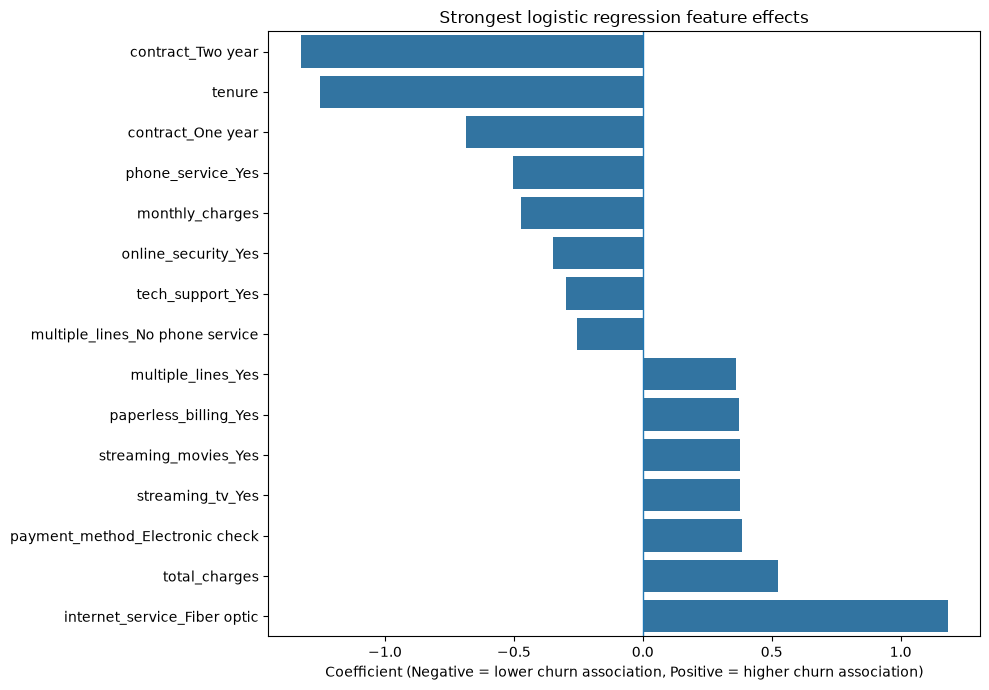

In [50]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="coefficient",
    y="feature"
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title(
    "Strongest logistic regression feature effects"
)

plt.xlabel(
    "Coefficient (Negative = lower churn association, "
    "Positive = higher churn association)"
)

plt.ylabel("")

plt.tight_layout()
plt.show()

## 5. Comparison with EDA findings


| Feature | EDA Finding | Logistic Regression | Interpretation |
|---|---|---|---|
| Tenure | New customers showed substantially higher churn | Strong negative coefficient | Longer tenure remains strongly associated with lower churn after accounting for other predictors |
| Contract | Month-to-month customers showed the highest churn | One- and two-year contracts have strong negative coefficients | Contract type remains one of the strongest churn indicators |
| Fiber optic | Fiber customers showed elevated churn | Strong positive coefficient | Fiber service remains associated with higher churn after adjustment |
| Electronic check | Electronic-check customers showed elevated churn | Positive coefficient | Payment method continues to provide predictive information |
| Online security | Customers with security showed lower churn | Negative coefficient | Security adoption remains associated with lower churn |
| Tech support | Customers with tech support showed lower churn | Negative coefficient | Tech support remains associated with lower churn |
| Senior citizen | Senior customers showed higher raw churn | Coefficient is close to zero | Much of the raw relationship may overlap with other modeled characteristics |
| Monthly charges | Churners had higher average monthly charges | Negative coefficient after adjustment | Effect changes after accounting for correlated service, tenure, and billing variables; interpretation requires caution |

## 5. Multicollinearity Analysis

Several numerical predictors, particularly tenure, monthly charges, and
total charges, are conceptually related. High correlation among predictors
can make individual logistic regression coefficients unstable and more
difficult to interpret.

Variance Inflation Factor (VIF) is therefore examined to assess
multicollinearity among the numerical predictors.

In [51]:
#investigating multicollinearity among the features using a correlation matrix
telco_clean_df[
    [
        "tenure",
        "monthly_charges",
        "total_charges"
    ]
].corr()

,tenure,monthly_charges,total_charges
tenure,1.000000,0.247900,0.826178
monthly_charges,0.247900,1.000000,0.651174
total_charges,0.826178,0.651174,1.000000


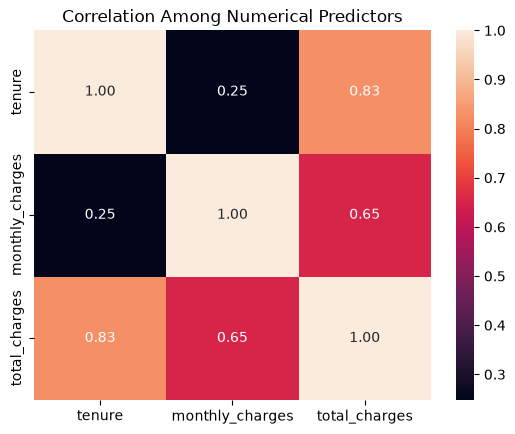

In [52]:
numeric_corr = telco_clean_df[
    ["tenure", "monthly_charges", "total_charges"]
].corr()

sns.heatmap(
    numeric_corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Among Numerical Predictors")
plt.show()

In [53]:
#calculating VIF for each feature
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = telco_clean_df[
    [
        "senior_citizen",
        "tenure",
        "monthly_charges",
        "total_charges"
    ]
].copy()

In [54]:
vif_table = pd.DataFrame()

vif_table["feature"] = vif_data.columns

vif_table["VIF"] = [
    variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])
]

vif_table.sort_values(
    "VIF",
    ascending=False
)

,feature,VIF
3,total_charges,8.080935
1,tenure,6.332627
2,monthly_charges,3.694794
0,senior_citizen,1.257276


In [55]:
import statsmodels.api as sm

vif_data = telco_clean_df[
    [
        "senior_citizen",
        "tenure",
        "monthly_charges",
        "total_charges"
    ]
].copy()

In [56]:
vif_table = pd.DataFrame()

vif_table["feature"] = vif_data.columns

vif_table["VIF"] = [
    variance_inflation_factor(
        vif_data.values,
        i
    )
    for i in range(vif_data.shape[1])
]

vif_table

,feature,VIF
0,senior_citizen,1.257276
1,tenure,6.332627
2,monthly_charges,3.694794
3,total_charges,8.080935


## 6. Multicollinearity Assessment

Variance Inflation Factor (VIF) was used to assess multicollinearity
among the numerical predictors.

The results indicate elevated multicollinearity for `tenure`
(VIF = 6.33) and `total_charges` (VIF = 8.08), while
`monthly_charges` shows moderate multicollinearity (VIF = 3.69).

This pattern is conceptually expected because total charges accumulate
over the duration of the customer relationship and are therefore closely
related to tenure and monthly billing levels.

Because multicollinearity can make logistic regression coefficients less
stable and more difficult to interpret, a reduced model excluding
`total_charges` will be evaluated as a sensitivity analysis rather than
removing the feature automatically.

In [57]:
#building the reduced feature set
X_reduced = X.drop(columns=["total_charges"])

In [58]:
numerical_features_reduced = [
    "senior_citizen",
    "tenure",
    "monthly_charges"
]

In [59]:
categorical_features_reduced = [
    col for col in X_reduced.columns if col not in numerical_features_reduced
]

In [60]:
#splitting the reduced feature set into training and testing sets with stratification
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [61]:
#rebuilding the preprocessing pipeline for the reduced feature set
preprocessor_reduced = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numerical_features_reduced),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features_reduced)
    ]
)

In [62]:
#fitting the logistic regression model on the reduced feature set
logistic_reduced = Pipeline(
    steps = [
        ("preprocessor", preprocessor_reduced),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

In [63]:
logistic_reduced.fit(
    X_train_reduced,
    y_train_reduced
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['gender','senior_citizen','partner',...,'paperless_billing', 'payment_method','monthly_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [64]:
#generating predictions on the reduced feature set
y_pred_reduced = logistic_reduced.predict(X_test_reduced)
y_prob_reduced = logistic_reduced.predict_proba(X_test_reduced)[:, 1]

In [65]:
#comparing the performance of the original and reduced feature set models
comparison = pd.DataFrame(
    [
        {
        "Model": [
            "Original logistic regression",
            "Reduced logistic regression"
        ],
        "Accuracy": [
            accuracy_score(y_test, y_pred),
            accuracy_score(y_test_reduced, y_pred_reduced)
        ],
        "Precision": [
            precision_score(y_test, y_pred),
            precision_score(y_test_reduced, y_pred_reduced)
        ],
        "Recall": [
            recall_score(y_test, y_pred),
            recall_score(y_test_reduced, y_pred_reduced)
        ],
        "F1": [
            f1_score(y_test, y_pred),
            f1_score(y_test_reduced, y_pred_reduced)
        ],
         "ROC_AUC": [
            roc_auc_score(y_test, y_prob),
            roc_auc_score(y_test_reduced, y_prob_reduced)
        ]
        }
    ]
)   

In [66]:
feature_names_reduced = (
    logistic_reduced
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients_reduced = (
    logistic_reduced
    .named_steps["classifier"]
    .coef_[0]
)

coef_reduced_df = pd.DataFrame({
    "feature": feature_names_reduced,
    "coefficient": coefficients_reduced
})

In [67]:
coef_reduced_df["feature"] = (
    coef_reduced_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

In [68]:
coef_reduced_df["odds_ratio"] = np.exp(
    coef_reduced_df["coefficient"]
)

In [69]:
coef_reduced_df.sort_values(
    "coefficient",
    ascending=False
).head(10)

,feature,coefficient,odds_ratio
9,internet_service_Fiber optic,1.227422,3.412421
22,streaming_movies_Yes,0.406667,1.501804
20,streaming_tv_Yes,0.406217,1.501129
8,multiple_lines_Yes,0.388311,1.474489
27,payment_method_Electronic check,0.382687,1.466220
25,paperless_billing_Yes,0.368381,1.445393
28,payment_method_Mailed check,0.103778,1.109354
16,device_protection_Yes,0.061392,1.063316
0,senior_citizen,0.053879,1.055356
3,gender_Male,0.022436,1.022690


In [70]:
coef_reduced_df.sort_values(
    "coefficient"
).head(10)

,feature,coefficient,odds_ratio
24,contract_Two year,-1.313303,0.268930
1,tenure,-0.803688,0.447675
23,contract_One year,-0.688953,0.502102
6,phone_service_Yes,-0.497956,0.607772
2,monthly_charges,-0.385045,0.680420
12,online_security_Yes,-0.329817,0.719055
7,multiple_lines_No phone service,-0.297283,0.742833
18,tech_support_Yes,-0.279083,0.756477
5,dependents_Yes,-0.235938,0.789830
15,device_protection_No internet service,-0.166660,0.846488


### Reduced Logistic Regression Feature Effects

The reduced logistic regression model, which excludes `total_charges`,
produces several feature effects that are consistent with the exploratory
analysis.

The strongest positive association with churn is observed for fiber optic
internet service. Fiber optic customers have substantially higher estimated
churn odds relative to the reference internet-service category after
accounting for other modeled customer characteristics.

Longer-term contracts show the strongest negative associations with churn.
One-year and particularly two-year contracts are associated with
substantially lower estimated churn odds than the reference contract
category.

Customer tenure also remains strongly negatively associated with churn,
although the magnitude of the tenure coefficient decreased after removing
`total_charges`, consistent with the multicollinearity observed between
these variables.

Online security and technical support remain associated with lower churn
odds, while electronic-check payment remains associated with higher churn
odds.

Several raw EDA relationships weaken substantially in the multivariate
model. Senior-citizen status, for example, showed higher churn during EDA
but has only a small positive coefficient after accounting for other
customer characteristics.

The negative coefficient for `monthly_charges` differs from the raw EDA
pattern. This suggests that monthly charges should be interpreted
conditionally: after accounting for service type, contract, tenure, and
other predictors, the incremental relationship between monthly charges
and churn differs from the unadjusted relationship observed during EDA.

## Updated EDA vs regression table 

| Feature          | EDA                               | Reduced logistic regression         | Conclusion                                    |
| ---------------- | --------------------------------- | ----------------------------------- | --------------------------------------------- |
| Tenure           | Short-tenure customers churn more | Strong negative effect              | Relationship persists after adjustment        |
| Contract         | Month-to-month highest churn      | One- and two-year strongly negative | One of the most robust churn relationships    |
| Fiber optic      | Elevated churn                    | OR ≈ 3.41                           | Strong positive association persists          |
| Electronic check | Elevated churn                    | OR ≈ 1.47                           | Association persists                          |
| Online security  | Lower churn                       | OR ≈ 0.72                           | Lower churn association persists              |
| Tech support     | Lower churn                       | OR ≈ 0.76                           | Lower churn association persists              |
| Senior citizen   | Higher raw churn                  | OR ≈ 1.06                           | Raw relationship largely attenuates           |
| Gender           | Little raw difference             | OR ≈ 1.02                           | Essentially no meaningful independent effect  |
| Monthly charges  | Higher among churners             | OR ≈ 0.68                           | Conditional relationship differs from raw EDA |


## 7. Original vs. Reduced Logistic Regression

In [71]:
#checking that we're comparing the same customers
len(y_test), len(y_test_reduced)

(1409, 1409)

In [72]:
(y_test.values == y_test_reduced.values).all()

np.True_

In [73]:
comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Reduced Logistic Regression"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test_reduced, y_pred_reduced)
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test_reduced, y_pred_reduced)
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test_reduced, y_pred_reduced)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test_reduced, y_pred_reduced)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test_reduced, y_prob_reduced)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Original Logistic Regression,0.806955,0.660377,0.561497,0.606936,0.842171
1,Reduced Logistic Regression,0.797019,0.637500,0.545455,0.587896,0.839306


In [74]:
comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Original Logistic Regression,0.807,0.660,0.561,0.607,0.842
1,Reduced Logistic Regression,0.797,0.638,0.545,0.588,0.839


In [75]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

performance_change = (
    comparison.loc[1, metrics]
    - comparison.loc[0, metrics]
)

performance_change

Accuracy    -0.009936
Precision   -0.022877
Recall      -0.016043
F1 Score    -0.019040
ROC-AUC     -0.002865
dtype: float64

In [76]:
comparison_display = comparison.set_index("Model").T

comparison_display["Difference"] = (
    comparison_display["Reduced Logistic Regression"]
    - comparison_display["Original Logistic Regression"]
)

comparison_display.round(3)

Model,Original Logistic Regression,Reduced Logistic Regression,Difference
Accuracy,0.807,0.797,-0.010
Precision,0.660,0.638,-0.023
Recall,0.561,0.545,-0.016
F1 Score,0.607,0.588,-0.019
ROC-AUC,0.842,0.839,-0.003


### Original vs. Reduced Model Comparison

Removing `total_charges` produced a small decline across all model
performance metrics. Accuracy decreased from **80.7% to 79.7%**, while
precision declined from **66.0% to 63.8%** and recall from **56.1% to
54.5%**. The F1-score decreased from **0.607 to 0.588**.

ROC-AUC declined only slightly, from **0.842 to 0.839**, suggesting that
the reduced model retains nearly the same overall ability to rank
customers by churn risk.

However, because the original specification performs better across all
evaluated metrics, `total_charges` is retained for the predictive
logistic regression benchmark.

The elevated VIF values for `total_charges` and `tenure` indicate that
individual coefficients for these related numerical variables should be
interpreted cautiously. The reduced model is therefore treated as a
sensitivity analysis rather than as the primary predictive specification.

## 8. ROC and Precision-Recall Analysis

While the default classification threshold provides one view of model
performance, predicted churn probabilities can be evaluated across a
range of possible thresholds.

ROC and precision-recall curves are used to examine the model's ability
to distinguish churners from non-churners and to visualize the trade-off
between identifying more churners and generating additional false-positive
predictions.

In [77]:
from sklearn.metrics import roc_curve

fpr, tpr, roc_threshold = roc_curve(
    y_test,
    y_prob
)

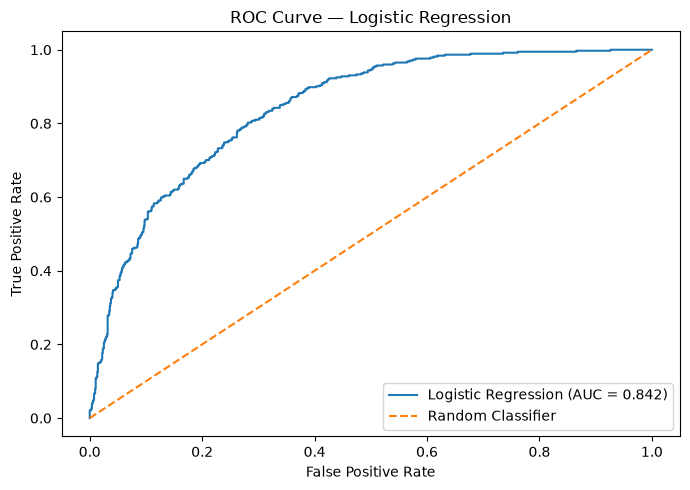

In [78]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression (AUC = 0.842)"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")

plt.legend()
plt.tight_layout()
plt.show()

### ROC Curve Interpretation

The logistic regression model achieved an ROC-AUC of **0.842**,
indicating good discrimination between customers who churn and customers
who remain.

The ROC curve remains substantially above the random-classifier diagonal
across thresholds, suggesting that the model's predicted probabilities
provide useful information for ranking customers by churn risk.

In [79]:
from sklearn.metrics import precision_recall_curve

In [80]:
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_prob
    )
)

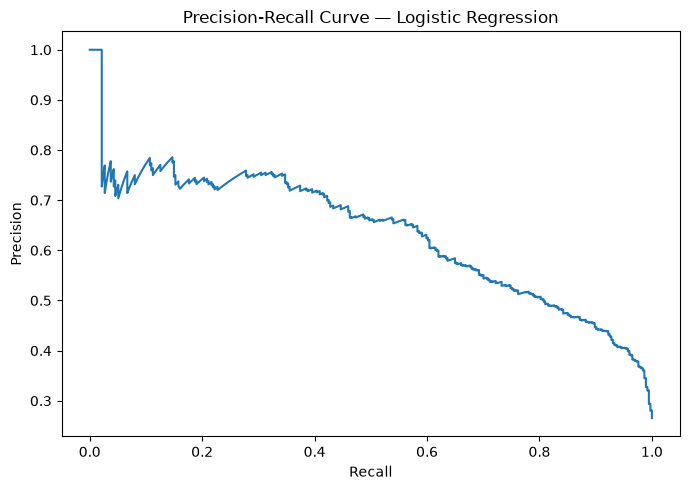

In [81]:
plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision-Recall Curve — Logistic Regression"
)

plt.tight_layout()
plt.show()

### Precision-Recall Interpretation

The precision-recall curve illustrates the trade-off between identifying
a larger proportion of actual churners and maintaining accuracy among
customers classified as high risk.

At the default classification threshold, the model achieves approximately
**66.0% precision** and **56.1% recall**.

Increasing recall would allow the company to identify more customers who
eventually churn, but would generally increase the number of false
positives and potentially the cost of unnecessary retention interventions.

The appropriate classification threshold should therefore ultimately be
selected based on the business costs associated with missed churners and
unnecessary retention targeting.

## 9. Decision tree classification

A decision tree is a nonlinear alternative to logistic regression.

Unlike logistic regression, a decision tree can capture nonlinear relationships and interactions between customer characteristics without requiring these relationships to be specified in advance.

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [83]:
numerical_features = [
    "senior_citizen",
    "tenure",
    "monthly_charges",
    "total_charges"
]

In [84]:
categorical_features = [
    col for col in X.columns if col not in numerical_features
]

In [85]:
#building the tree preprocessing pipeline
tree_preprocessor = ColumnTransformer(
    transformers = [
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [86]:
tree_model = Pipeline(
    steps = [
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=20,
            random_state=42
        ))
    ]
)

In [87]:
#training the decision tree model
tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [88]:
#training predictions
tree_train_pred_controlled = (tree_model.predict(X_train))

In [89]:
#testing predictions
tree_pred = tree_model.predict(X_test)

tree_prob = tree_model.predict_proba(X_test)[:, 1]

In [90]:
#comparing the training and test performance
controlled_train_accuracy = accuracy_score(
    y_train, tree_train_pred_controlled
)

controlled_test_accuracy = accuracy_score(
    y_test, tree_pred
)

print(
    f"Training accuracy: {controlled_train_accuracy: .3f}"
)

print(
    f"Test accuracy: {controlled_test_accuracy: .3f}"
)

Training accuracy:  0.803
Test accuracy:  0.798


In [91]:
#calculating the controlled_tree metrics
tree_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score": [
        accuracy_score(y_test, tree_pred),
        precision_score(y_test, tree_pred),
        recall_score(y_test, tree_pred),
        f1_score(y_test, tree_pred),
        roc_auc_score(y_test, tree_prob)
    ]
})

tree_metrics.round(3)

,Metric,Score
0,Accuracy,0.798
1,Precision,0.635
2,Recall,0.567
3,F1 Score,0.599
4,ROC-AUC,0.828


In [92]:
#visualizing the tree
tree_feature_names = (
    tree_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

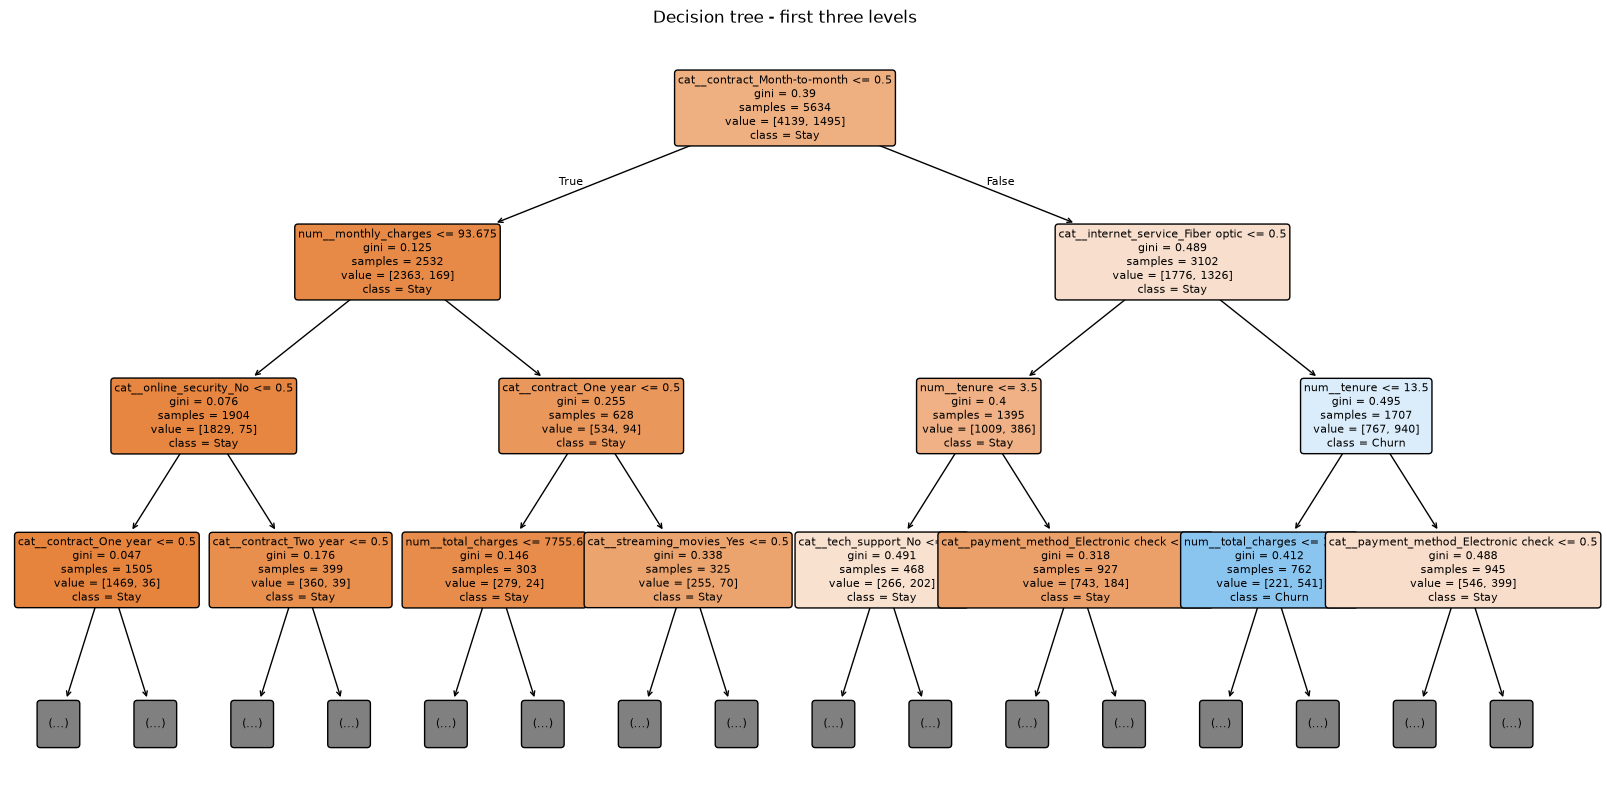

In [93]:
plt.figure(figsize=(20,10))

plot_tree(
    tree_model.named_steps["classifier"],
    feature_names=tree_feature_names,
    class_names=["Stay", "Churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision tree - first three levels")

plt.show()

In [94]:
#inspecting feature importance
tree_importance = (
    tree_model
    .named_steps["classifier"]
    .feature_importances_
)

In [95]:
tree_importance_df = pd.DataFrame({
    "feature": tree_feature_names,
    "importance": tree_importance
})

In [96]:
tree_importance_df["feature"] = (
    tree_importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

In [97]:
tree_importance_df.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,importance
36,contract_Month-to-month,0.517673
16,internet_service_Fiber optic,0.164438
1,tenure,0.154620
2,monthly_charges,0.038483
3,total_charges,0.033084
43,payment_method_Electronic check,0.028132
27,tech_support_No,0.021531
37,contract_One year,0.009285
21,online_backup_No,0.009264
18,online_security_No,0.008682


### Decision Tree Performance

The controlled Decision Tree achieved an accuracy of **79.8%**, precision
of **63.5%**, recall of **56.7%**, F1-score of **0.599**, and ROC-AUC of
**0.828**.

Compared with logistic regression, the Decision Tree achieved slightly
higher recall but lower accuracy, precision, F1-score, and ROC-AUC.
Therefore, the nonlinear tree model does not currently provide an overall
predictive improvement over the logistic regression benchmark.

The small increase in recall indicates that the Decision Tree identifies
slightly more actual churners at the default classification threshold,
but this comes at the cost of a greater proportion of false-positive
predictions.

### Decision Tree Feature Importance

The Decision Tree relies heavily on a small number of predictors.
`contract_Month-to-month` is the dominant feature, followed by
`internet_service_Fiber optic` and `tenure`.

Together, these three features account for the majority of the
tree's impurity-based feature importance.

These results are consistent with both the exploratory analysis and
logistic regression findings, strengthening the evidence that contract
structure, internet-service type, and customer tenure are central
predictors of churn risk.

Payment method, technical support, online security, and billing variables
provide additional predictive information, although their contribution
to the fitted tree is substantially smaller.

Decision Tree feature importance reflects the contribution of predictors
to impurity reduction and should not be interpreted as a causal effect or
as the percentage of churn explained by each variable.

| Feature          | EDA                       | Logistic Regression         | Decision Tree          | Overall evidence                      |
| ---------------- | ------------------------- | --------------------------- | ---------------------- | ------------------------------------- |
| Contract         | Very strong               | Very strong                 | Strongest tree feature | **Very strong**                       |
| Tenure           | Very strong               | Strong negative association | Top-3 feature          | **Very strong**                       |
| Fiber optic      | High churn                | Strong positive association | #2 tree feature        | **Very strong**                       |
| Electronic check | High churn                | Positive association        | Used by tree           | **Strong**                            |
| Tech support     | Lower churn with support  | Negative association        | `No` used by tree      | **Strong**                            |
| Online security  | Lower churn with security | Negative association        | `No` used by tree      | **Strong**                            |
| Senior citizen   | Strong raw difference     | Very weak adjusted effect   | Very low importance    | **Mostly explained by other factors** |
| Gender           | Almost no difference      | Negligible                  | Not important          | **Very weak**                         |


## 10. Random forest classification

A random forest classifier is evaluated to determine whether combining multiple decision trees can improve predictive performance over a single decision tree and the logistic regression benchmark.

Random forest can capture nonlinear relationships and interactions while reducing the instability and overfitting associated with individual decision trees.

In [98]:
from sklearn.ensemble import RandomForestClassifier

In [99]:
#building the initial random forest
random_forest = Pipeline(
    steps=[
        (
            "preprocessor", tree_preprocessor
        ),
        (
            "classifier", RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [100]:
#training the model
random_forest.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [ ]:
#generating predictions 